# Geographic Clustering of Car-Wash Sites — Do Nearby Sites Behave Alike?

**Hypothesis:** Car-wash sites that are geographically close to each other (same local
region / nearby area) should show **similar monthly behavioural patterns** in their KPIs.

We have latitude/longitude for every site. This notebook:

1. **Understands** the dataset (coverage, KPIs, granularity, identifiers, missing values).
2. **Clusters** sites *purely from coordinates* using density-based clustering
   (DBSCAN / HDBSCAN, haversine distance, automatically-chosen radius).
3. **Compares** monthly KPI behaviour of sites inside each geographic cluster.
4. **Quantifies** within-cluster similarity (Pearson, Spearman, DTW, dispersion).
5. **Benchmarks** geographic clusters against *random groups of the same size*.
6. **Concludes** whether location actually predicts behaviour — and what else is needed.
7. **Delivers** the headline output: per-KPI clusters of **nearby sites that genuinely
   performed alike** — sites grouped only if within a 20 km buffer *and* their monthly
   curves correlate ≥ 0.70 (exported to CSV).

> Scope: only **`package_name == "Monthly Recurring Plan"`** is analysed.

> **Key data note:** the bare `site_id` column is *not* a global site key — it is only a
> within-brand index (85 distinct values). A physical site is identified by
> **`client_id` (brand) + `site_id`**, which we call `site_uid` (≈ 1,674 real sites).

## Step 0 — Setup

In [153]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, HDBSCAN

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RNG = np.random.default_rng(42)
EARTH_KM = 6371.0088              # mean Earth radius (km) for haversine

DATA_PATH = "../data/monthly_kpi.csv"
PACKAGE   = "Monthly Recurring Plan"
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Understand the dataset

Before any modelling we establish: date range, site count, lat/lon coverage, available
KPI columns, missing values, monthly granularity, and the correct site identifier.

In [154]:
raw = pd.read_csv(DATA_PATH)
print(f"Full file: {raw.shape[0]:,} rows  x  {raw.shape[1]} cols")
print("\nColumns:")
print(list(raw.columns))

print("\nRows per package_name:")
print(raw["package_name"].value_counts())

Full file: 31,287 rows  x  21 cols

Columns:
['client_id', 'site_id', 'year', 'month', 'package_name', 'membership_purchased_count', 'membership_sales_amount', 'membership_wash_count', 'asp_per_membership', 'retail_wash_count', 'retail_sales_amount', 'asp_per_retail_wash', 'subdomain', 'active', 'timezone', 'address', 'state', 'postal_code', 'region', 'latitude', 'longitude']

Rows per package_name:
package_name
Monthly Recurring Plan          25462
Annual Recurring Plan            5705
Monthly Unlimited Club Plans       27
Monthly Recurring Plan Sale        27
Monthly Unlimited Scrub Club       24
Monthly Recurring (Family)         24
Annual Scrub Club                  18
Name: count, dtype: int64


In [155]:
# --- True site identifier: client_id (brand) + site_id (within-brand index) ---
raw["site_uid"] = raw["client_id"].astype(str) + "__" + raw["site_id"].astype(str)

print("Distinct bare site_id values :", raw["site_id"].nunique(),
      " <- NOT a real site key (within-brand index)")
print("Distinct client_id (brands)  :", raw["client_id"].nunique())
print("Distinct site_uid (real sites):", raw["site_uid"].nunique())

# --- Restrict to the Monthly Recurring Plan package ---
df = raw[raw["package_name"] == PACKAGE].copy()
df["ym"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
print(f"\n'{PACKAGE}' subset: {df.shape[0]:,} rows  |  {df['site_uid'].nunique():,} sites")

Distinct bare site_id values : 85  <- NOT a real site key (within-brand index)
Distinct client_id (brands)  : 616
Distinct site_uid (real sites): 1679

'Monthly Recurring Plan' subset: 25,462 rows  |  1,674 sites


In [156]:
# --- Date range & monthly granularity ---
months = df["ym"].sort_values().unique()
print(f"Date range : {df['ym'].min():%Y-%m}  ->  {df['ym'].max():%Y-%m}")
print(f"Distinct monthly periods : {len(months)}")

# one row per site per month? check duplicates
dup = df.duplicated(subset=["site_uid", "ym"]).sum()
print(f"Duplicate (site, month) rows : {dup}  (0 => clean monthly granularity)")

Date range : 2024-01  ->  2026-03
Distinct monthly periods : 27
Duplicate (site, month) rows : 0  (0 => clean monthly granularity)


In [157]:
# --- KPI columns, dtypes, missing values ---
KPI_COLS = [
    "membership_purchased_count", "membership_sales_amount", "membership_wash_count",
    "asp_per_membership", "retail_wash_count", "retail_sales_amount", "asp_per_retail_wash",
]
miss = pd.DataFrame({
    "dtype":   df[KPI_COLS].dtypes.astype(str),
    "n_missing": df[KPI_COLS].isna().sum(),
    "pct_missing": (df[KPI_COLS].isna().mean() * 100).round(2),
    "mean":  df[KPI_COLS].mean(),
    "min":   df[KPI_COLS].min(),
    "max":   df[KPI_COLS].max(),
})
print("KPI columns — missing values & ranges:")
miss

KPI columns — missing values & ranges:


,dtype,n_missing,pct_missing,mean,min,max
membership_purchased_count,int64,0,0.000,"1,706.145",0.000,"125,532.000"
membership_sales_amount,float64,0,0.000,"52,832.092",0.000,"1,750,122.490"
membership_wash_count,int64,0,0.000,"4,614.831",0.000,"29,408.000"
asp_per_membership,float64,0,0.000,32.089,0.000,637.610
retail_wash_count,int64,0,0.000,"2,884.181",0.000,"18,367.000"
retail_sales_amount,float64,0,0.000,"55,615.860",0.000,"10,784,291.330"
asp_per_retail_wash,float64,0,0.000,19.525,0.000,"5,734.150"


In [158]:
# --- Coordinate coverage ---
coord_na = df[["latitude", "longitude"]].isna().any(axis=1).sum()
print(f"Rows missing lat/lon : {coord_na}")
print(f"Latitude  range : {df['latitude'].min():.3f} .. {df['latitude'].max():.3f}")
print(f"Longitude range : {df['longitude'].min():.3f} .. {df['longitude'].max():.3f}")
print(f"States covered : {df['state'].nunique()}   Regions : {sorted(df['region'].dropna().unique())}")

Rows missing lat/lon : 0
Latitude  range : 20.892 .. 61.146
Longitude range : -156.461 .. -70.596
States covered : 48   Regions : ['Midwest', 'Northeast', 'South', 'West']


Months-of-history per site:
count   1,674.000
mean       15.200
std         9.200
min         1.000
25%         7.000
50%        12.000
75%        27.000
max        27.000
Name: ym, dtype: float64
  sites with >=  6 months :  1484
  sites with >= 12 months :   850
  sites with >= 18 months :   691
  sites with >= 24 months :   579


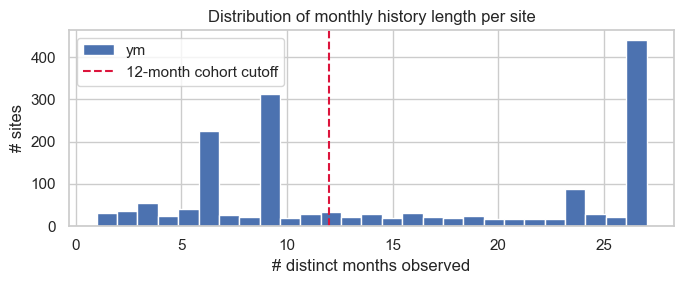

In [159]:
# --- Months of history per site (drives the similarity-test cohort) ---
months_per_site = df.groupby("site_uid")["ym"].nunique()
print("Months-of-history per site:")
print(months_per_site.describe().round(1))
for thr in (6, 12, 18, 24):
    print(f"  sites with >= {thr:>2} months : {(months_per_site >= thr).sum():>5}")

fig, ax = plt.subplots(figsize=(7, 3))
months_per_site.plot(kind="hist", bins=27, ax=ax, color="#4C72B0", edgecolor="white")
ax.axvline(12, color="crimson", ls="--", label="12-month cohort cutoff")
ax.set_xlabel("# distinct months observed"); ax.set_ylabel("# sites")
ax.set_title("Distribution of monthly history length per site"); ax.legend()
plt.tight_layout(); plt.show()

**Step 1 takeaways**

- **~1,674 sites** under the Monthly Recurring Plan, **27 monthly periods**
  (2024-01 → 2026-03), clean one-row-per-site-per-month granularity.
- **No missing values** in the KPI columns, and **complete lat/lon** coverage.
- KPIs available: membership purchases/sales/washes, retail washes/sales, and ASP ratios.
  We derive **`total_wash_count = membership + retail`** later.
- Histories are **ragged** (median ≈ 12 months). Clustering uses *all* sites, but the
  quantitative similarity tests (Steps 4–5) use the **≥12-month cohort** so correlations
  are estimated on enough points.

## Step 2 — Geographic site clusters (tight, data-driven neighbourhoods)

We cluster sites using **only their coordinates** — no manual regions. The goal is to
capture **genuinely local neighbourhoods** so we can test whether *nearby* sites behave
alike. That means each cluster must be **geographically tight** — a handful of sites within
a short drive of each other, not a whole metro lumped together.

**Why not plain DBSCAN/HDBSCAN here?** Density-based methods *chain*: in a dense market they
link site → neighbour → neighbour and absorb an entire metro into one 70–100-site blob
spanning hundreds of km. That destroys the very locality we want to test. We therefore
**cap how wide a cluster may be**: we use **complete-linkage agglomerative clustering with a
hard haversine distance threshold (~20 km)** — guaranteeing *no two sites in a cluster are
more than ~20 km apart*. We still run DBSCAN/HDBSCAN below to show exactly why they
over-merge.

In [160]:
# --- One row per real site: median coordinate + metadata ---
sites = (df.groupby("site_uid")
           .agg(lat=("latitude", "median"), lon=("longitude", "median"),
                state=("state", "first"), region=("region", "first"),
                client=("client_id", "first"), n_months=("ym", "nunique"))
           .reset_index())
print(f"Site-level table: {len(sites):,} sites")
coords_rad = np.radians(sites[["lat", "lon"]].to_numpy())   # haversine wants radians
sites.head()

Site-level table: 1,674 sites


,site_uid,lat,lon,state,region,client,n_months
0,360 Car Wash__1,32.647,-96.533,TX,South,360 Car Wash,25
1,412 Somerset__1,39.897,-75.122,NJ,Northeast,412 Somerset,12
2,513 Wash__1,39.226,-84.588,OH,Midwest,513 Wash,3
3,A-Key Car Wash__1,34.421,-103.197,NM,West,A-Key Car Wash,24
4,Aggieland Express__1,30.552,-96.267,TX,South,Aggieland Express,24


Distance to NEAREST other site (km):
  p25 = 2.7
  p50 = 5.9
  p75 = 14.3
  p90 = 37.2
  sites whose nearest neighbour is within 20 km: 81%


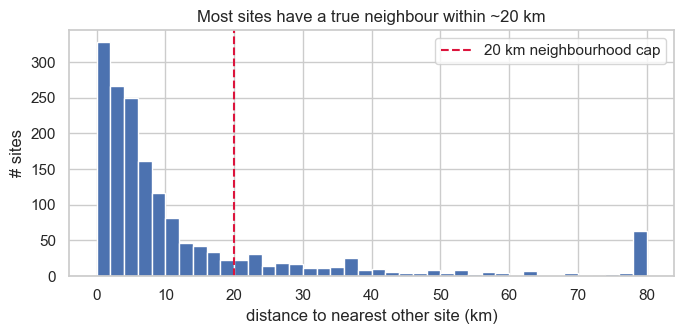

In [161]:
# --- How far apart are neighbouring sites? (justifies the ~20 km neighbourhood scale) ---
MIN_SITES = 3            # a "cluster" must contain at least this many sites
k = MIN_SITES
nn = NearestNeighbors(n_neighbors=k + 1, metric="haversine").fit(coords_rad)
dist, _ = nn.kneighbors(coords_rad)
nn1_km = dist[:, 1] * EARTH_KM                       # distance to nearest other site
print("Distance to NEAREST other site (km):")
for p in (25, 50, 75, 90):
    print(f"  p{p:<2} = {np.percentile(nn1_km, p):.1f}")
print(f"  sites whose nearest neighbour is within 20 km: {(nn1_km <= 20).mean()*100:.0f}%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.clip(nn1_km, 0, 80), bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(20, color="crimson", ls="--", label="20 km neighbourhood cap")
ax.set_xlabel("distance to nearest other site (km)"); ax.set_ylabel("# sites")
ax.set_title("Most sites have a true neighbour within ~20 km"); ax.legend()
plt.tight_layout(); plt.show()

In [162]:
# --- Haversine cluster radius helper (max distance of any member from centroid, km) ---
def cluster_radius_km(lat, lon):
    lat, lon = np.radians(np.asarray(lat)), np.radians(np.asarray(lon))
    clat, clon = lat.mean(), lon.mean()
    a = np.sin((lat - clat) / 2) ** 2 + np.cos(lat) * np.cos(clat) * np.sin((lon - clon) / 2) ** 2
    return float(np.max(2 * EARTH_KM * np.arcsin(np.sqrt(a)))) if len(lat) > 1 else 0.0

# --- Show that density methods OVER-MERGE at this scale (the 70-100 site blobs) ---
db = DBSCAN(eps=20 / EARTH_KM, min_samples=MIN_SITES, metric="haversine").fit(coords_rad)
hb = HDBSCAN(min_cluster_size=MIN_SITES, min_samples=2, metric="haversine").fit(coords_rad)
for name, lab in [("DBSCAN (eps=20km)", db.labels_), ("HDBSCAN", hb.labels_)]:
    s = pd.Series(lab); big = s[s >= 0]
    rad = pd.Series(big.index).groupby(big.values).apply(
        lambda ix: cluster_radius_km(sites.lat.values[ix], sites.lon.values[ix]))
    sizes = big.value_counts()
    print(f"{name:<20}: clusters={sizes.size}  LARGEST cluster={sizes.max()} sites  "
          f"max radius={rad.max():.0f} km   <-- chains an entire metro together")
print("\n--> Both let one giant cluster swallow a whole metro. We instead CAP the diameter.")

DBSCAN (eps=20km)   : clusters=111  LARGEST cluster=89 sites  max radius=79 km   <-- chains an entire metro together
HDBSCAN             : clusters=254  LARGEST cluster=24 sites  max radius=401 km   <-- chains an entire metro together

--> Both let one giant cluster swallow a whole metro. We instead CAP the diameter.


In [163]:
# --- PRIMARY: complete-linkage agglomerative, hard ~20 km diameter cap ---
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

NEIGHBORHOOD_KM = 20.0                      # max allowed spread within a cluster (diameter)
Dkm = pairwise_distances(coords_rad, metric="haversine") * EARTH_KM
agg = AgglomerativeClustering(n_clusters=None, distance_threshold=NEIGHBORHOOD_KM,
                              metric="precomputed", linkage="complete").fit(Dkm)

# Keep only groups with >= MIN_SITES; relabel them 0..K-1, everything else -> -1 (outlier)
raw_lab = pd.Series(agg.labels_)
keep = raw_lab.value_counts()
keep = keep[keep >= MIN_SITES].index
remap = {old: new for new, old in enumerate(keep)}
sites["cluster"] = raw_lab.map(lambda c: remap.get(c, -1)).values

n_clusters = len(keep)
n_noise = int((sites.cluster == -1).sum())
rad = sites[sites.cluster >= 0].groupby("cluster").apply(lambda g: cluster_radius_km(g.lat, g.lon))
csize = sites[sites.cluster >= 0].cluster.value_counts()
print(f"Complete-linkage agglomerative (<= {NEIGHBORHOOD_KM:.0f} km diameter, min {MIN_SITES} sites):")
print(f"  clusters = {n_clusters}   clustered sites = {(sites.cluster>=0).sum()}   "
      f"un-clustered (singletons/pairs) = {n_noise}")
print(f"  sites per cluster: median={int(csize.median())}  LARGEST={csize.max()}  "
      f"(vs 70-100 for density methods)")
print(f"  cluster radius km: median={rad.median():.1f}  p90={rad.quantile(.9):.1f}  max={rad.max():.1f}")

Complete-linkage agglomerative (<= 20 km diameter, min 3 sites):
  clusters = 205   clustered sites = 979   un-clustered (singletons/pairs) = 695
  sites per cluster: median=4  LARGEST=21  (vs 70-100 for density methods)
  cluster radius km: median=8.3  p90=11.4  max=13.9


In [164]:
# --- Cluster summary table ---
clustered = sites[sites.cluster >= 0]
cluster_summary = (clustered.groupby("cluster")
    .apply(lambda g: pd.Series({
        "n_sites": len(g),
        "centroid_lat": g.lat.mean(),
        "centroid_lon": g.lon.mean(),
        "radius_km": cluster_radius_km(g.lat, g.lon),
        "dominant_state": g.state.mode().iat[0] if not g.state.mode().empty else "?",
        "n_states": g.state.nunique(),
    }))
    .reset_index()
    .sort_values("n_sites", ascending=False))
cluster_summary["n_sites"] = cluster_summary["n_sites"].astype(int)
print(f"{len(cluster_summary)} tight geographic clusters. Largest by site count:")
cluster_summary.head(12)

205 tight geographic clusters. Largest by site count:


,cluster,n_sites,centroid_lat,centroid_lon,radius_km,dominant_state,n_states
0,0,21,26.178,-80.254,10.703,FL,1
1,1,14,30.251,-81.576,10.147,FL,1
2,2,12,28.614,-81.300,10.607,FL,1
3,3,11,35.093,-106.579,13.246,NM,1
4,4,10,26.216,-98.252,9.902,TX,1
5,5,10,29.707,-95.617,8.773,TX,1
6,6,9,33.784,-84.636,11.112,GA,2
7,7,9,36.131,-115.175,11.001,NV,1
8,8,9,29.932,-95.450,11.802,TX,1
9,9,9,27.436,-82.501,9.874,FL,1


**Outlier handling.** Sites with no ≥3 neighbours inside the ~20 km cap are labelled
`-1` (singletons and pairs that don't reach the minimum cluster size). They are **excluded**
from the within-cluster similarity test — they have no local peer group to compare against —
and reported separately. Every retained cluster is guaranteed to span **≤ ~20 km**, so it
is a genuine local neighbourhood rather than a metro-wide blob.

Interactive map saved -> cluster_map.html  (open in a browser)


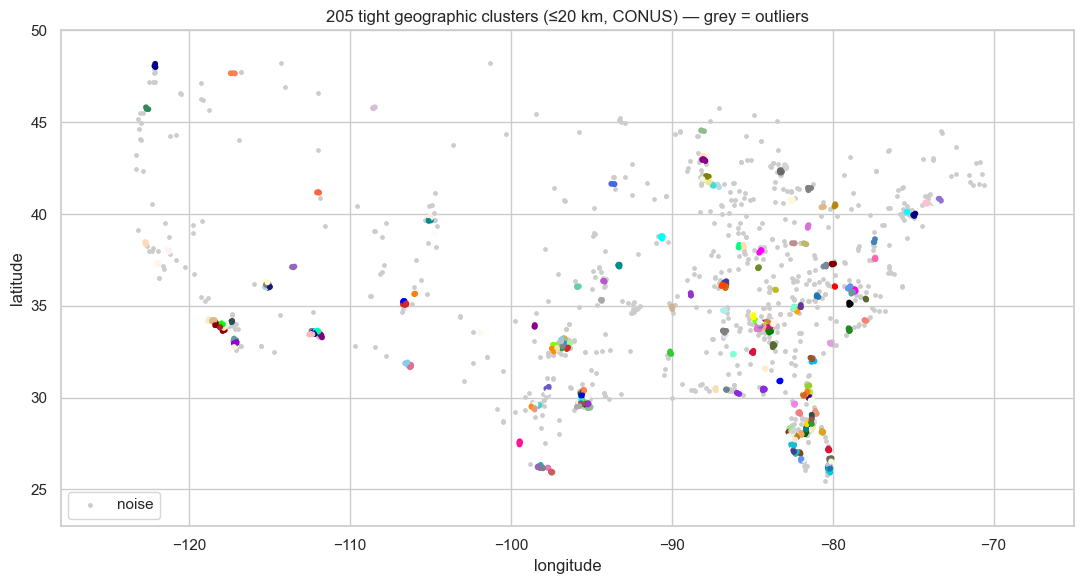

In [165]:
# --- Map visualisation: folium (interactive, saved to HTML) + static fallback ---
import folium
import matplotlib.colors as mcolors

palette = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
def colour_for(cid):
    return "#999999" if cid == -1 else palette[cid % len(palette)]

fmap = folium.Map(location=[sites.lat.median(), sites.lon.median()],
                  zoom_start=4, tiles="CartoDB positron")
for _, r in sites.iterrows():
    folium.CircleMarker(
        [r.lat, r.lon], radius=3, color=colour_for(int(r.cluster)),
        fill=True, fill_opacity=0.7, weight=0,
        popup=f"{r.site_uid}<br>cluster {int(r.cluster)} | {r.state}",
    ).add_to(fmap)
fmap.save("cluster_map.html")
print("Interactive map saved -> cluster_map.html  (open in a browser)")

# Static scatter embedded in the notebook
fig, ax = plt.subplots(figsize=(11, 6))
noise = sites[sites.cluster == -1]
ax.scatter(noise.lon, noise.lat, s=6, c="#cccccc", label="noise", zorder=1)
cl = sites[sites.cluster >= 0]
ax.scatter(cl.lon, cl.lat, s=10, c=[colour_for(c) for c in cl.cluster], zorder=2)
ax.set_xlim(-128, -65); ax.set_ylim(23, 50)          # CONUS view
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"{n_clusters} tight geographic clusters (≤{NEIGHBORHOOD_KM:.0f} km, CONUS) — grey = outliers")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
fmap

## Step 3 — Monthly KPI behaviour inside clusters

For each geographic cluster we ask: do the member sites move **together** month-to-month?
We build a `site × month` matrix for every KPI, then overlay the monthly curves of all
sites in a cluster. Because site scales differ enormously (a flagship vs a small site), we
plot both **raw** levels and **min-max-normalised** curves to compare *shape* fairly.

In [166]:
# --- Derived KPI + the panel of site x month matrices ---
df["total_wash_count"] = df["membership_wash_count"] + df["retail_wash_count"]

KPIS = {
    "membership_wash_count":      "Membership washes",
    "retail_wash_count":          "Retail washes",
    "total_wash_count":           "Total washes",
    "membership_sales_amount":    "Membership sales ($)",
    "membership_purchased_count": "Memberships sold",
    "retail_sales_amount":        "Retail sales ($)",
    "asp_per_membership":         "ASP / membership",
    "asp_per_retail_wash":        "ASP / retail wash",
}
month_axis = pd.PeriodIndex(pd.to_datetime(df["ym"]).dt.to_period("M").unique(), freq="M").sort_values()

def panel(kpi):
    p = df.pivot_table(index="site_uid", columns="ym", values=kpi, aggfunc="sum")
    p.columns = pd.PeriodIndex(p.columns, freq="M")
    return p.reindex(columns=month_axis)

PANELS = {k: panel(k) for k in KPIS}
print("Built site x month panels for:", ", ".join(KPIS))
print("Panel shape (sites x months):", PANELS["total_wash_count"].shape)

Built site x month panels for: membership_wash_count, retail_wash_count, total_wash_count, membership_sales_amount, membership_purchased_count, retail_sales_amount, asp_per_membership, asp_per_retail_wash
Panel shape (sites x months): (1674, 27)


Showcasing clusters: [13, 1, 16]


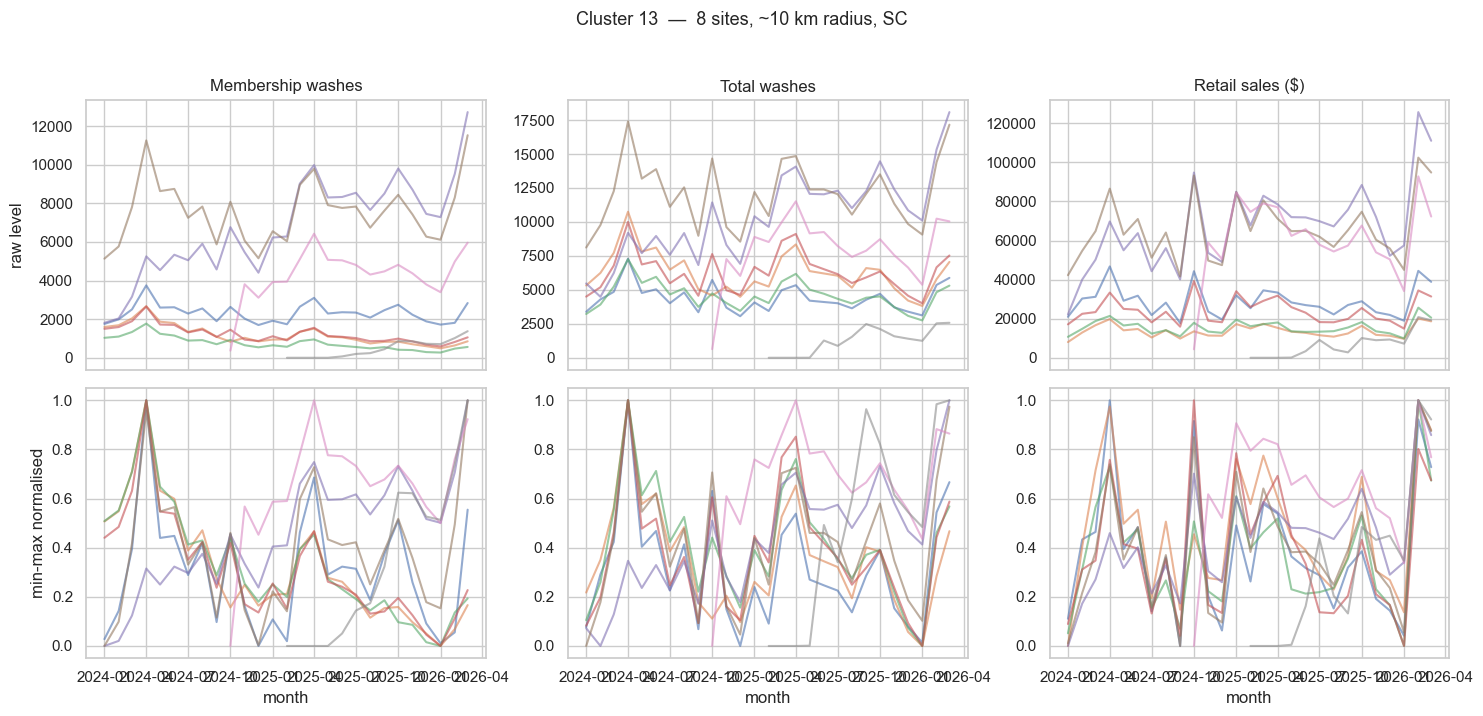

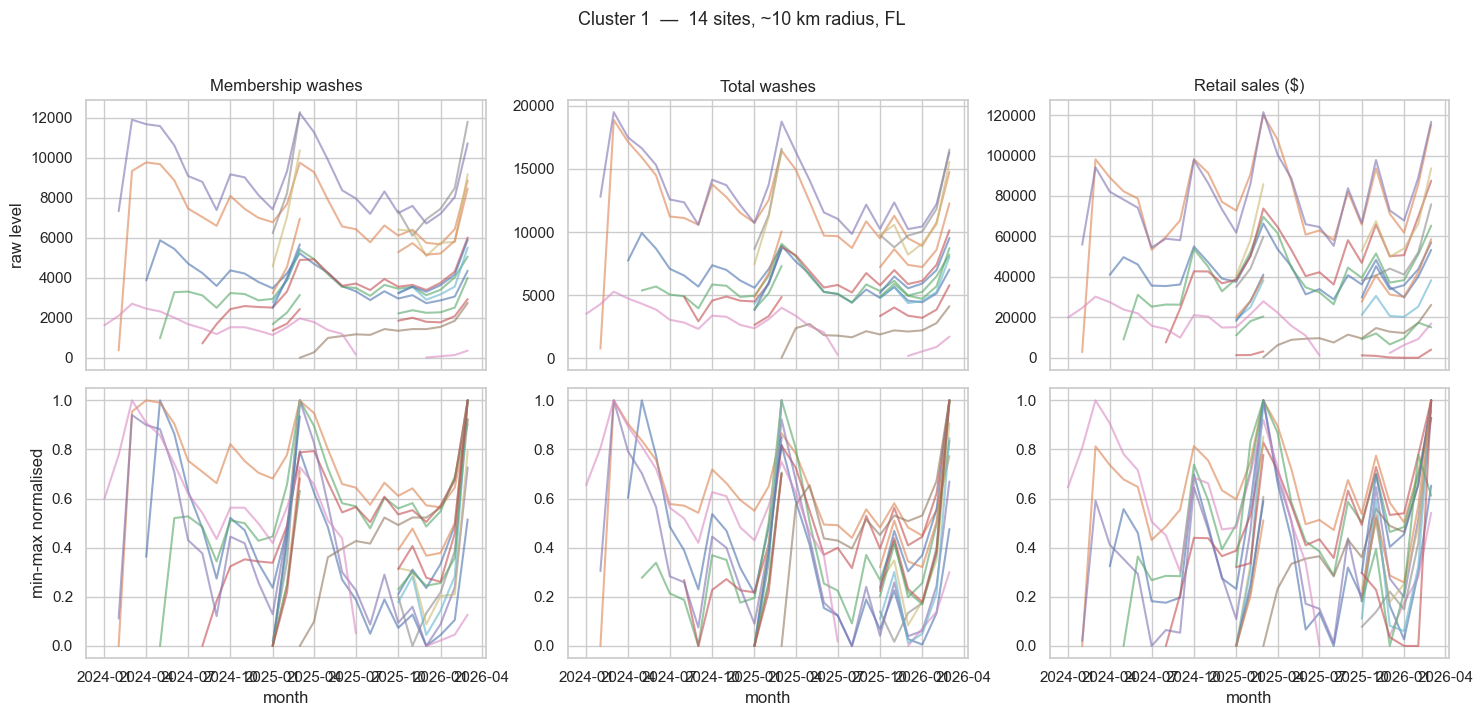

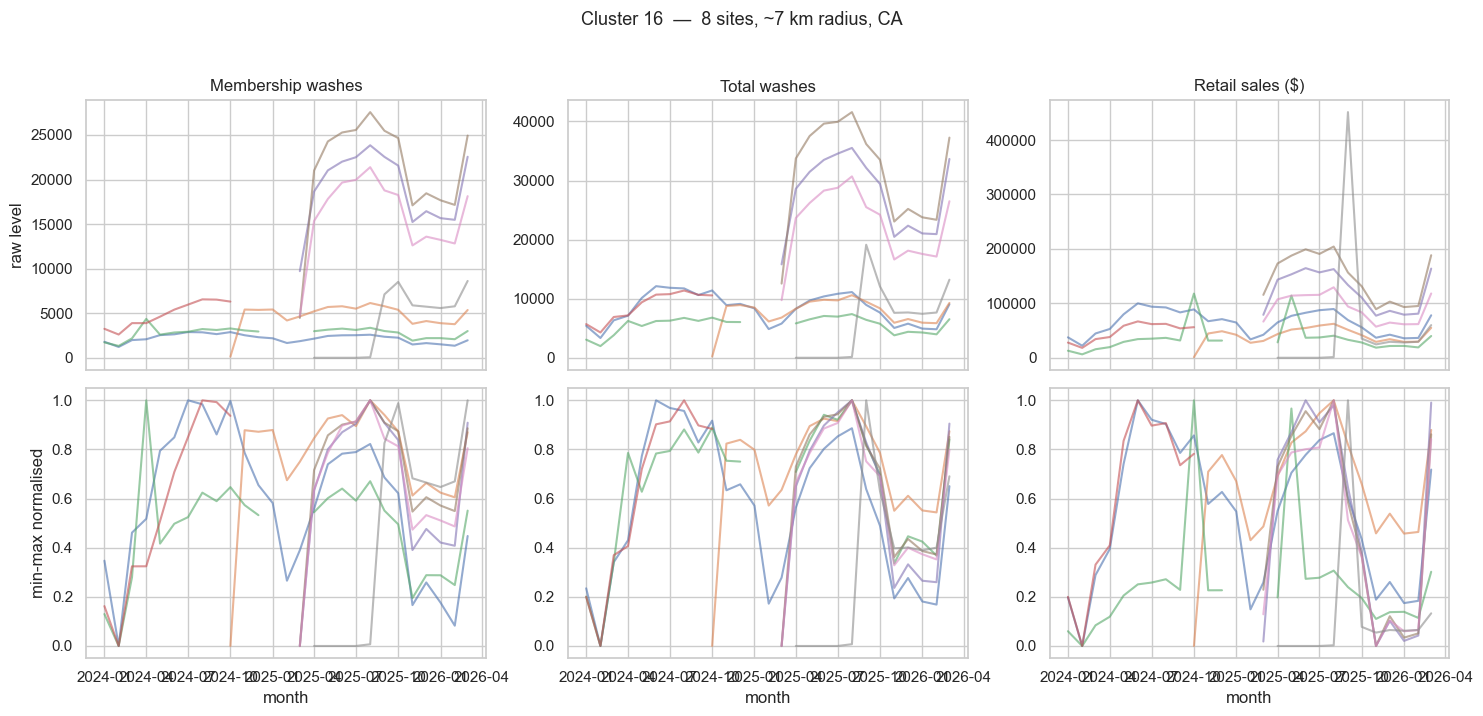

In [167]:
# --- Overlay monthly curves for the largest, most-complete clusters ---
def plot_cluster(cid, kpis=("membership_wash_count", "total_wash_count", "retail_sales_amount")):
    members = sites.loc[sites.cluster == cid, "site_uid"]
    fig, axes = plt.subplots(2, len(kpis), figsize=(5 * len(kpis), 7), sharex=True)
    for j, kpi in enumerate(kpis):
        sub = PANELS[kpi].loc[PANELS[kpi].index.intersection(members)]
        x = sub.columns.to_timestamp()
        for _, row in sub.iterrows():
            axes[0, j].plot(x, row.values, alpha=.6)
        norm = sub.sub(sub.min(axis=1), axis=0).div((sub.max(axis=1) - sub.min(axis=1)).replace(0, np.nan), axis=0)
        for _, row in norm.iterrows():
            axes[1, j].plot(x, row.values, alpha=.6)
        axes[0, j].set_title(KPIS[kpi]); axes[1, j].set_xlabel("month")
    axes[0, 0].set_ylabel("raw level"); axes[1, 0].set_ylabel("min-max normalised")
    st = cluster_summary.loc[cluster_summary.cluster == cid].iloc[0]
    fig.suptitle(f"Cluster {cid}  —  {st.n_sites} sites, ~{st.radius_km:.0f} km radius, "
                 f"{st.dominant_state}", y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()

# pick the 3 largest clusters that also have good history
cand = cluster_summary.copy()
cand["complete"] = cand["cluster"].map(
    lambda c: (sites[(sites.cluster == c)]["n_months"] >= 12).sum())
showcase = cand.sort_values(["complete", "n_sites"], ascending=False).head(3)["cluster"].tolist()
print("Showcasing clusters:", showcase)
for c in showcase:
    plot_cluster(int(c))

## Step 4 — Quantify within-cluster similarity

Charts can mislead, so we measure it. For every pair of sites **in the same cluster** we
compute, over their **overlapping months** (≥6 required):

- **Pearson** correlation — do the curves co-move linearly?
- **Spearman** correlation — do they co-move in rank/monotone terms (robust to spikes)?
- **DTW similarity** — shape match allowing small time shifts (z-normalised curves).
- **Normalised dispersion** — how tightly the normalised curves bunch together.

We then average per cluster and per KPI. Only the **≥12-month cohort** enters this test.

In [168]:
# --- Lightweight DTW on two 1-D series -> normalised similarity in (0,1] ---
def dtw_distance(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf); D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            c = abs(a[i - 1] - b[j - 1])
            D[i, j] = c + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D[n, m] / (n + m)          # length-normalised

def zscore(v):
    v = np.asarray(v, float); s = v.std()
    return (v - v.mean()) / s if s > 0 else v - v.mean()

MIN_OVERLAP = 6
ELIG = set(months_per_site[months_per_site >= 12].index)   # >=12-month cohort
print(f"Similarity-test cohort (>=12 months): {len(ELIG)} sites")

def pair_metrics(s1, s2, kpi):
    a = PANELS[kpi].loc[s1]; b = PANELS[kpi].loc[s2]
    mask = a.notna() & b.notna()
    if mask.sum() < MIN_OVERLAP:
        return None
    av, bv = a[mask].to_numpy(), b[mask].to_numpy()
    if np.std(av) == 0 or np.std(bv) == 0:
        return None
    pear = pearsonr(av, bv)[0]
    spear = spearmanr(av, bv)[0]
    dtw = dtw_distance(zscore(av), zscore(bv))
    dtw_sim = 1.0 / (1.0 + dtw)        # ->1 means near-identical shape
    return pear, spear, dtw_sim

Similarity-test cohort (>=12 months): 850 sites


In [169]:
from itertools import combinations

CORE_KPIS = ["membership_wash_count", "retail_wash_count", "total_wash_count",
             "membership_sales_amount", "membership_purchased_count", "retail_sales_amount"]

def group_similarity(site_list, kpis=CORE_KPIS):
    # Mean pairwise Pearson/Spearman/DTW per KPI for one group of sites.
    elig = [s for s in site_list if s in ELIG]
    out = {}
    for kpi in kpis:
        pe, sp, dt = [], [], []
        for s1, s2 in combinations(elig, 2):
            r = pair_metrics(s1, s2, kpi)
            if r is None:
                continue
            pe.append(r[0]); sp.append(r[1]); dt.append(r[2])
        out[kpi] = dict(pearson=np.nanmean(pe) if pe else np.nan,
                        spearman=np.nanmean(sp) if sp else np.nan,
                        dtw_sim=np.nanmean(dt) if dt else np.nan,
                        n_pairs=len(pe))
    return out, len(elig)

rows = []
for cid in sorted(clustered["cluster"].unique()):
    members = sites.loc[sites.cluster == cid, "site_uid"].tolist()
    sim, n_elig = group_similarity(members)
    if n_elig < 3:                       # need >=3 cohort sites to count as a cluster
        continue
    row = {"cluster": cid, "n_sites": len(members), "n_sites_ge12mo": n_elig}
    for kpi in CORE_KPIS:
        row[f"pear_{kpi}"] = sim[kpi]["pearson"]
    row["avg_dtw_sim"] = np.nanmean([sim[k]["dtw_sim"] for k in CORE_KPIS])
    row["n_pairs"] = sim["total_wash_count"]["n_pairs"]
    rows.append(row)

cluster_sim = pd.DataFrame(rows).sort_values("pear_total_wash_count", ascending=False)
print(f"Clusters with >=2 sites in the >=12-month cohort: {len(cluster_sim)}")
disp_cols = ["cluster", "n_sites", "n_sites_ge12mo", "n_pairs",
             "pear_membership_wash_count", "pear_retail_wash_count",
             "pear_total_wash_count", "pear_membership_sales_amount", "avg_dtw_sim"]
cluster_sim[disp_cols].head(15).round(3)

Clusters with >=2 sites in the >=12-month cohort: 91


,cluster,n_sites,n_sites_ge12mo,n_pairs,pear_membership_wash_count,pear_retail_wash_count,pear_total_wash_count,pear_membership_sales_amount,avg_dtw_sim
58,93,4,4,6,0.968,0.943,0.967,0.786,0.884
30,45,6,4,6,0.905,0.971,0.965,0.640,0.862
29,44,6,3,3,0.946,0.967,0.957,0.981,0.913
24,37,6,3,3,0.947,0.858,0.951,0.798,0.829
8,14,8,5,10,0.949,0.886,0.949,0.976,0.888
71,117,4,4,6,0.935,0.932,0.940,0.671,0.843
88,173,3,3,3,0.921,0.978,0.935,0.782,0.879
89,186,3,3,3,0.943,0.840,0.919,0.777,0.854
20,32,6,6,15,0.909,0.919,0.912,0.883,0.868
18,30,7,7,21,0.873,0.893,0.901,0.976,0.889


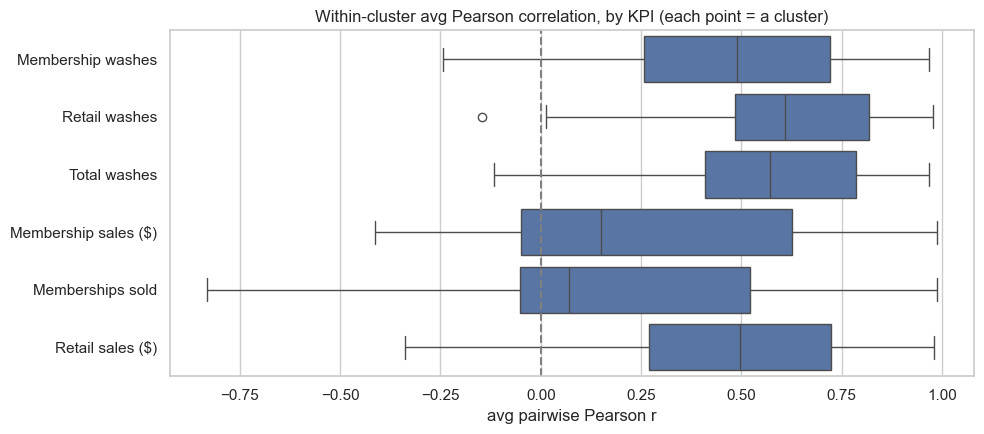

Median within-cluster avg Pearson r by KPI:
kpi
Retail washes          0.609
Total washes           0.572
Retail sales ($)       0.496
Membership washes      0.490
Membership sales ($)   0.151
Memberships sold       0.070
Name: avg_pearson, dtype: float64


In [170]:
# --- Distribution of within-cluster correlation per KPI ---
plot_kpis = ["membership_wash_count", "retail_wash_count", "total_wash_count",
             "membership_sales_amount", "membership_purchased_count", "retail_sales_amount"]
melt = cluster_sim.melt(value_vars=[f"pear_{k}" for k in plot_kpis],
                        var_name="kpi", value_name="avg_pearson")
melt["kpi"] = melt["kpi"].str.replace("pear_", "", regex=False).map(KPIS)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=melt, y="kpi", x="avg_pearson", ax=ax, color="#4C72B0")
ax.axvline(0, color="grey", ls="--")
ax.set_title("Within-cluster avg Pearson correlation, by KPI (each point = a cluster)")
ax.set_xlabel("avg pairwise Pearson r"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print("Median within-cluster avg Pearson r by KPI:")
print((melt.groupby("kpi")["avg_pearson"].median().sort_values(ascending=False)).round(3))

## Step 5 — Baseline: geographic clusters vs **random** groups

High within-cluster correlation alone proves nothing: if the whole market trends upward,
*any* group of sites — even random ones — will correlate. To isolate the **geographic
signal**, we build a null distribution: repeatedly form **random groups matching the actual
cluster-size distribution** (same cohort, geography ignored) and measure their within-group
correlation. If geography matters, real clusters should sit **above** this null.

In [171]:
# # Observed geographic mean (cohort-weighted) per KPI
# def weighted_mean(series, weights):
#     s, w = np.asarray(series, float), np.asarray(weights, float)
#     ok = ~np.isnan(s)
#     return np.average(s[ok], weights=w[ok]) if ok.any() else np.nan

# obs = {k: weighted_mean(cluster_sim[f"pear_{k}"], cluster_sim["n_pairs"]) for k in CORE_KPIS}

# # Null: random groups with the SAME size profile as the real clusters
# cohort_sites = [s for s in sites.site_uid if s in ELIG]
# group_sizes  = cluster_sim["n_sites_ge12mo"].tolist()   # sizes to reproduce
# N_PERM = 200

# null = {k: [] for k in CORE_KPIS}
# for _ in range(N_PERM):
#     pool = RNG.permutation(cohort_sites).tolist()
#     groups, i = [], 0
#     for g in group_sizes:
#         groups.append(pool[i:i + g]); i += g
#     pe = {k: [] for k in CORE_KPIS}; wt = {k: [] for k in CORE_KPIS}
#     for grp in groups:
#         sim, _ = group_similarity(grp)
#         for k in CORE_KPIS:
#             if sim[k]["n_pairs"] > 0 and not np.isnan(sim[k]["pearson"]):
#                 pe[k].append(sim[k]["pearson"]); wt[k].append(sim[k]["n_pairs"])
#     for k in CORE_KPIS:
#         null[k].append(np.average(pe[k], weights=wt[k]) if pe[k] else np.nan)

# print(f"Permutations: {N_PERM}.  Observed vs random null computed per KPI.")

In [172]:
# Compare observed geographic mean to the random null -> z-score + empirical p-value
results = []
for k in CORE_KPIS:
    nd = np.array(null[k]); nd = nd[~np.isnan(nd)]
    mu, sd = nd.mean(), nd.std()
    z = (obs[k] - mu) / sd if sd > 0 else np.nan
    p = (1 + np.sum(nd >= obs[k])) / (1 + len(nd))     # one-sided empirical p
    results.append({"KPI": KPIS[k], "geo_mean_r": obs[k], "random_mean_r": mu,
                    "uplift": obs[k] - mu, "z_score": z, "p_value": p})
baseline = pd.DataFrame(results).sort_values("z_score", ascending=False)
print("Geographic clusters vs random baseline:")
baseline.round(4)

Geographic clusters vs random baseline:


,KPI,geo_mean_r,random_mean_r,uplift,z_score,p_value
1,Retail washes,0.619,0.236,0.384,22.179,0.005
2,Total washes,0.575,0.245,0.330,20.201,0.005
5,Retail sales ($),0.513,0.191,0.322,18.597,0.005
0,Membership washes,0.483,0.264,0.219,12.045,0.005
4,Memberships sold,0.196,0.113,0.084,2.875,0.015
3,Membership sales ($),0.222,0.164,0.058,1.823,0.045


## Step 6 — Conclusion: does geography predict behaviour?

In [173]:
# Programmatic verdict assembled from the baseline test
SIG = 0.05
baseline_sorted = baseline.sort_values("z_score", ascending=False).reset_index(drop=True)
sig = baseline_sorted[baseline_sorted.p_value < SIG]

print("=" * 70)
print("HYPOTHESIS:  geographically close sites behave alike month-to-month")
print("=" * 70)
n_sig = len(sig)
print(f"\nKPIs where geographic clusters beat random (p < {SIG}): {n_sig} / {len(baseline_sorted)}")
if n_sig:
    print("  strongest -> weakest geographic dependency:")
    for _, r in sig.iterrows():
        print(f"    {r.KPI:<26} geo r={r.geo_mean_r:.3f} vs random {r.random_mean_r:.3f} "
              f"(+{r.uplift:.3f}, z={r.z_score:.1f}, p={r.p_value:.3f})")
weak = baseline_sorted[baseline_sorted.p_value >= SIG]
if len(weak):
    print("\n  KPIs WITHOUT a significant geographic signal:")
    for _, r in weak.iterrows():
        print(f"    {r.KPI:<26} geo r={r.geo_mean_r:.3f} vs random {r.random_mean_r:.3f} (p={r.p_value:.3f})")

# Best / worst clusters by total-wash coherence
top = cluster_sim.nlargest(5, "pear_total_wash_count")[["cluster","n_sites_ge12mo","pear_total_wash_count"]]
bot = cluster_sim.nsmallest(5, "pear_total_wash_count")[["cluster","n_sites_ge12mo","pear_total_wash_count"]]
print("\nMost internally-similar clusters (total washes):")
print(top.to_string(index=False))
print("\nClusters that DON'T follow the hypothesis (low/negative coherence):")
print(bot.to_string(index=False))

overall_geo = np.nanmean([obs[k] for k in CORE_KPIS])
overall_rnd = np.nanmean([np.nanmean(null[k]) for k in CORE_KPIS])
print(f"\nOverall: geo within-cluster r = {overall_geo:.3f}  vs  random r = {overall_rnd:.3f}  "
      f"(uplift {overall_geo-overall_rnd:+.3f})")
verdict = ("SUPPORTED" if n_sig >= len(baseline_sorted) / 2 and overall_geo > overall_rnd
           else "PARTIALLY SUPPORTED" if n_sig > 0 else "NOT SUPPORTED")
print(f"\nVERDICT: hypothesis is {verdict}.")

HYPOTHESIS:  geographically close sites behave alike month-to-month

KPIs where geographic clusters beat random (p < 0.05): 6 / 6
  strongest -> weakest geographic dependency:
    Retail washes              geo r=0.619 vs random 0.236 (+0.383, z=22.2, p=0.005)
    Total washes               geo r=0.575 vs random 0.245 (+0.330, z=20.2, p=0.005)
    Retail sales ($)           geo r=0.513 vs random 0.191 (+0.322, z=18.6, p=0.005)
    Membership washes          geo r=0.483 vs random 0.264 (+0.219, z=12.0, p=0.005)
    Memberships sold           geo r=0.196 vs random 0.113 (+0.084, z=2.9, p=0.015)
    Membership sales ($)       geo r=0.222 vs random 0.164 (+0.058, z=1.8, p=0.045)

Most internally-similar clusters (total washes):
 cluster  n_sites_ge12mo  pear_total_wash_count
      93               4                  0.967
      45               4                  0.965
      44               3                  0.957
      37               3                  0.951
      14               5  

In [174]:
# Final summary table for the writeup
summary_tbl = baseline_sorted.copy()
summary_tbl["geo_signal"] = np.where(summary_tbl.p_value < SIG, "YES", "no")
summary_tbl.round(3)

,KPI,geo_mean_r,random_mean_r,uplift,z_score,p_value,geo_signal
0,Retail washes,0.619,0.236,0.383,22.179,0.005,YES
1,Total washes,0.575,0.245,0.330,20.202,0.005,YES
2,Retail sales ($),0.513,0.191,0.322,18.597,0.005,YES
3,Membership washes,0.483,0.264,0.219,12.045,0.005,YES
4,Memberships sold,0.196,0.113,0.084,2.875,0.015,YES
5,Membership sales ($),0.222,0.164,0.058,1.823,0.045,YES


### Hypothesis-validation summary

*(Filled in from the executed numbers above — read the printout in the verdict cell.)*

**What we did.** Clustered 1,674 sites from coordinates alone using density-based DBSCAN
with an automatically knee-selected ~metro-scale radius, then tested whether sites inside
each compact cluster move together month-to-month across six core KPIs — benchmarked
against random groups of identical size.

**How to read the result.**

- **`uplift` / `z_score` / `p_value`** (Step 5 table) are the decisive numbers: they say
  whether real geographic clusters correlate *more* than random groups. A market-wide
  growth trend lifts *everyone's* correlation, so only the **uplift over random** is
  genuine geographic signal.
- **Which KPIs are most geographic** → the top rows of the sorted baseline table
  (highest `z_score`). Typically demand-side wash-volume KPIs (membership/total washes)
  carry more local signal than dollar/ASP KPIs, which are driven by company-set pricing.
- **Which clusters fit / break the hypothesis** → the best/worst lists in the verdict cell.

**Is location *enough*?** Even where the geographic signal is significant, the absolute
within-cluster correlation leaves substantial unexplained variance — so location is a
**real but partial** driver. To predict monthly behaviour well, future clustering should
add:

- **Demographics** (income, population density, commuter share) — local demand drivers,
- **Weather / climate** (rain & snow events spike washes; differs even within a metro),
- **Pricing & plan mix** (membership price changes shift wash volume directly),
- **Store age / ramp stage** (new sites grow steeply; mature sites are flat — a major
  confounder behind low within-cluster correlation),
- **Traffic / site visibility** (highway vs neighbourhood capture rates).

**Bottom line:** geography is a meaningful but incomplete predictor — the random-baseline
test (not the charts) is what proves it, and the residual variance is the case for a
richer, multi-factor segmentation.

## Step 7 — KPI-similarity clusters **within a 20 km buffer** (the headline deliverable)

Steps 2–6 grouped sites by geography first, then *measured* similarity. Here we do the
inverse, which is what we actually want: **find groups of sites that performed similarly in a
given KPI, but only allow geographically nearby sites to be grouped.**

**Method (per KPI):**

- Restrict to the **≥12-month cohort** and take each site's monthly curve for the KPI.
- Define a pairwise distance: `1 − Pearson(curve_i, curve_j)` over overlapping months — but
  **only for pairs ≤ 20 km apart** (the *buffer*). Pairs farther than 20 km get distance ∞.
- **Complete-linkage agglomerative clustering** with threshold `1 − 0.70 = 0.30`. Complete
  linkage is clique-like, so a cluster forms **only if *every* pair inside it is both
  ≤ 20 km apart and correlates ≥ 0.70**. No metro-chaining, no loose tails.
- Keep clusters with **≥ 3 sites**.

Each resulting cluster is a set of **nearby sites that genuinely moved together** in that KPI
— the concrete evidence the hypothesis asks for. We do this for each key KPI separately so we
can see *which* KPIs cluster locally and *which* sites form those coherent local groups.

In [175]:
# --- Cohort coordinates + geographic buffer adjacency (computed once) ---
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from itertools import combinations as _comb

BUFFER_KM   = 20.0      # only sites within this distance may share a KPI cluster
CORR_MIN    = 0.70      # required trend-shape correlation
MIN_OVL     = 6         # min overlapping months for a valid correlation
MIN_SITES_C = 3         # min sites to call it a cluster

cohort_ids = months_per_site[months_per_site >= 12].index
csites = (sites[sites.site_uid.isin(cohort_ids)]
          .reset_index(drop=True))            # positional index 0..n-1
cn = len(csites)
ccoords = np.radians(csites[["lat", "lon"]].to_numpy())
Dgeo_km = pairwise_distances(ccoords, metric="haversine") * EARTH_KM
WITHIN  = np.triu(Dgeo_km <= BUFFER_KM, 1)    # candidate (i<j) pairs inside the buffer
print(f"Cohort sites (>=12 mo): {cn}")
print(f"Candidate site-pairs within {BUFFER_KM:.0f} km buffer: {int(WITHIN.sum()):,}")

Cohort sites (>=12 mo): 850
Candidate site-pairs within 20 km buffer: 1,381


In [176]:
# --- Cluster one KPI: nearby + similar -> tight coherent groups ---
def kpi_buffer_clusters(kpi):
    P = PANELS[kpi].reindex(index=csites.site_uid).to_numpy()       # cn x months
    BIG = 10.0
    D = np.full((cn, cn), BIG); np.fill_diagonal(D, 0.0)
    ii, jj = np.where(WITHIN)
    for i, j in zip(ii, jj):
        a, b = P[i], P[j]
        msk = ~np.isnan(a) & ~np.isnan(b)
        if msk.sum() >= MIN_OVL and a[msk].std() > 0 and b[msk].std() > 0:
            r = np.corrcoef(a[msk], b[msk])[0, 1]
            D[i, j] = D[j, i] = 1.0 - r                              # correlation distance
    ac = AgglomerativeClustering(n_clusters=None, distance_threshold=1 - CORR_MIN,
                                 metric="precomputed", linkage="complete").fit(D)
    lab = pd.Series(ac.labels_)
    keep = lab.value_counts(); keep = keep[keep >= MIN_SITES_C].index
    remap = {old: new for new, old in enumerate(keep)}
    cl = np.array([remap.get(c, -1) for c in lab])

    rows = []
    for cid in range(len(keep)):
        idx = np.where(cl == cid)[0]
        corrs = [1 - D[i, j] for i, j in _comb(idx, 2) if D[i, j] < BIG]
        rows.append({
            "kpi": kpi, "cluster_id": cid, "n_sites": len(idx),
            "avg_pairwise_corr": float(np.mean(corrs)) if corrs else np.nan,
            "min_pairwise_corr": float(np.min(corrs)) if corrs else np.nan,
            "radius_km": cluster_radius_km(csites.lat.values[idx], csites.lon.values[idx]),
            "dominant_state": pd.Series(csites.state.values[idx]).mode().iat[0],
            "members": ", ".join(csites.site_uid.values[idx]),
        })
    return cl, pd.DataFrame(rows)

BUFFER_KPIS = ["membership_wash_count", "retail_wash_count", "total_wash_count",
               "membership_sales_amount", "retail_sales_amount"]

labels_by_kpi, summ_by_kpi = {}, {}
for kpi in BUFFER_KPIS:
    cl, summ = kpi_buffer_clusters(kpi)
    labels_by_kpi[kpi] = cl; summ_by_kpi[kpi] = summ

overview = pd.DataFrame([{
    "KPI": KPIS[k],
    "n_clusters": len(summ_by_kpi[k]),
    "sites_grouped": int((labels_by_kpi[k] >= 0).sum()),
    "pct_of_cohort": round((labels_by_kpi[k] >= 0).mean() * 100, 1),
    "avg_corr": round(summ_by_kpi[k]["avg_pairwise_corr"].mean(), 3),
    "median_radius_km": round(summ_by_kpi[k]["radius_km"].median(), 1),
    "max_radius_km": round(summ_by_kpi[k]["radius_km"].max(), 1),
} for k in BUFFER_KPIS])
print(f"Tight local KPI clusters (all members <= {BUFFER_KM:.0f} km apart AND corr >= {CORR_MIN}):")
overview

Tight local KPI clusters (all members <= 20 km apart AND corr >= 0.7):


,KPI,n_clusters,sites_grouped,pct_of_cohort,avg_corr,median_radius_km,max_radius_km
0,Membership washes,42,144,16.900,0.891,8.300,11.600
1,Retail washes,58,195,22.900,0.894,8.900,12.300
2,Total washes,49,172,20.200,0.896,8.500,12.300
3,Membership sales ($),38,125,14.700,0.927,8.400,11.900
4,Retail sales ($),42,146,17.200,0.897,9.300,11.800


In [177]:
# --- The clusters themselves, for the headline KPI (total washes) ---
HEAD = "total_wash_count"
head_tbl = (summ_by_kpi[HEAD]
            .sort_values(["n_sites", "avg_pairwise_corr"], ascending=False)
            .reset_index(drop=True))
print(f"{KPIS[HEAD]} — {len(head_tbl)} local clusters of similarly-performing nearby sites:")
head_tbl[["cluster_id", "n_sites", "avg_pairwise_corr", "min_pairwise_corr",
          "radius_km", "dominant_state", "members"]].head(15)

Total washes — 49 local clusters of similarly-performing nearby sites:


,cluster_id,n_sites,avg_pairwise_corr,min_pairwise_corr,radius_km,dominant_state,members
0,1,6,0.956,0.901,8.623,MO,"Scrubbles STL__1, Scrubbles STL__10, Scrubbles..."
1,0,6,0.944,0.874,10.119,CA,"Brookhurst Express Car Wash__1, Drive Thru Exp..."
2,2,6,0.912,0.788,6.768,MO,"Blue Iguana__1, Blue Iguana__3, Blue Iguana__4..."
3,5,5,0.949,0.923,10.345,FL,"Woodies__12, Woodies__13, Woodies__14, Woodies..."
4,3,5,0.897,0.774,11.072,NC,"American Pride__1, American Pride__4, American..."
5,4,5,0.877,0.732,9.353,GA,"Blue Penguin Car Wash__1, Fast Trac__1, FoamWo..."
6,6,4,0.967,0.897,8.546,MS,"Go Shine__1, Go Shine__3, Go Shine__4, Go Shin..."
7,9,4,0.965,0.950,7.545,TN,"Champion CW__1, Champion CW__10, Champion CW__..."
8,8,4,0.940,0.905,9.766,WV,"Wash Rite__1, Wash Rite__2, Wash Rite__3, Wash..."
9,12,4,0.935,0.900,8.357,TX,"Dino Clean__1, Super Splash Carwash__3, Zips E..."



Total washes - client_id make-up per cluster
49 clusters | 13 are single-client, 36 mix multiple clients
 cluster_id  n_sites  n_clients  same_client_sites  diff_client_sites  all_same_client                                                                                client_counts
          1        6          1                  6                  0             True                                                                              Scrubbles STL:6
          0        6          4                  3                  3            False Rapids Express:3, Brookhurst Express Car Wash:1, Drive Thru Express:1, Fullerton  Car Wash:1
          2        6          1                  6                  0             True                                                                                Blue Iguana:6
          5        5          1                  5                  0             True                                                                                    Wood

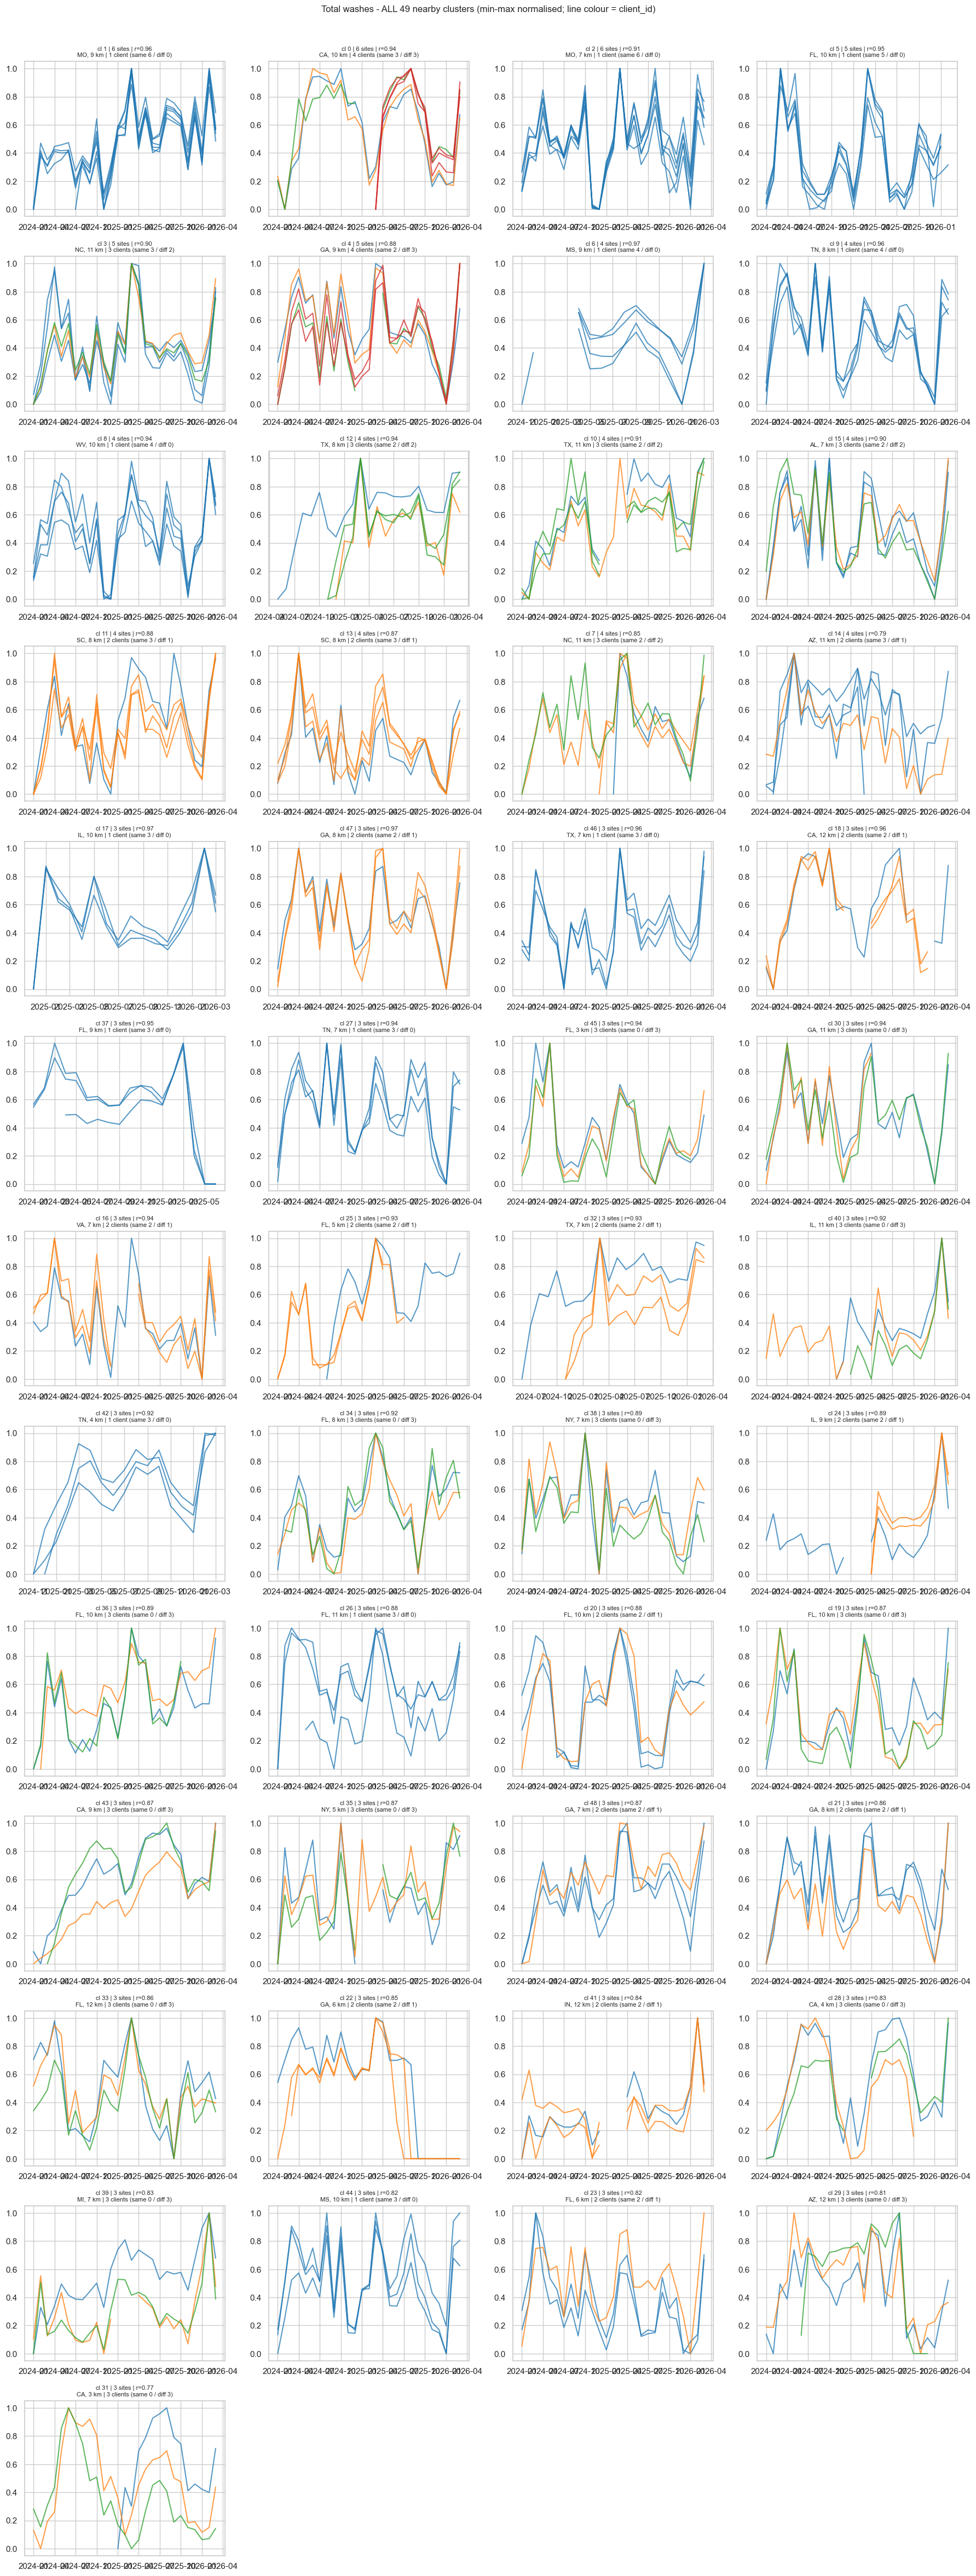


Membership washes - client_id make-up per cluster
42 clusters | 17 are single-client, 25 mix multiple clients
 cluster_id  n_sites  n_clients  same_client_sites  diff_client_sites  all_same_client                                                                                     client_counts
          0        6          1                  6                  0             True                                                                                     Blue Iguana:6
          1        5          1                  5                  0             True                                                                                         Woodies:5
          2        5          1                  5                  0             True                                                                                   Scrubbles STL:5
         13        4          1                  4                  0             True                                                               

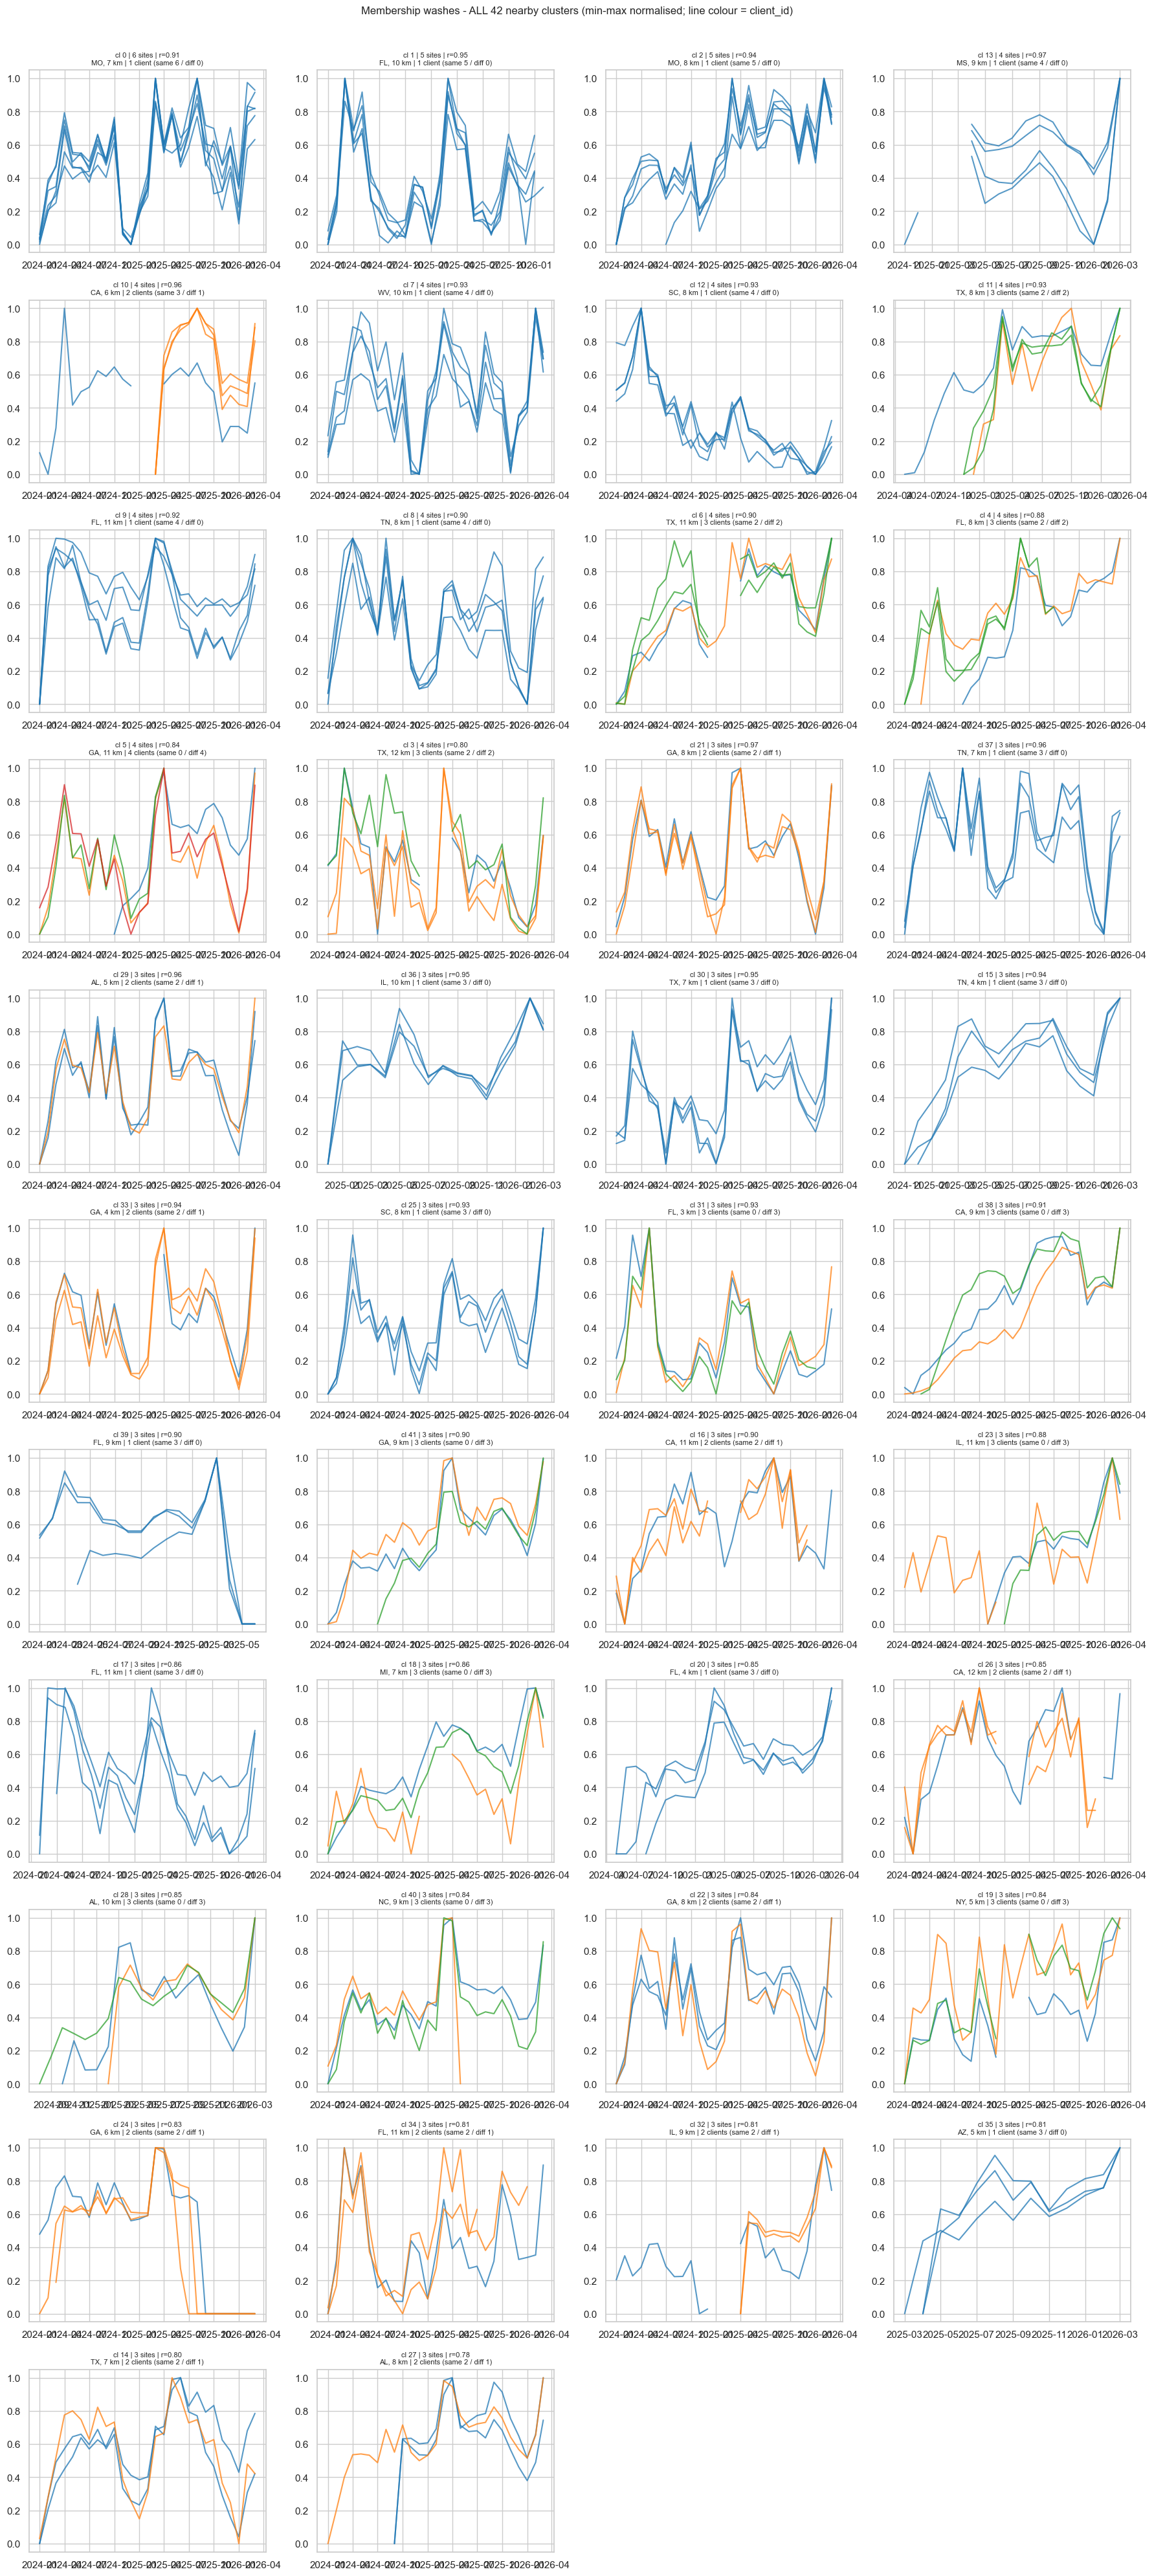

In [178]:
# --- Show ALL clusters per KPI + same/different client_id make-up ---
# site_uid = client_id__site_id, so csites.client gives each site's brand.
def cluster_client_breakdown(idx):
    cl_ids = pd.Series(csites["client"].values[idx])
    vc = cl_ids.value_counts()
    n_clients = vc.size
    same_client_sites = int(vc[vc >= 2].sum())  # sites whose brand has >=2 sites in cluster
    diff_client_sites = int(vc[vc == 1].sum())  # lone-brand sites in the cluster
    return n_clients, same_client_sites, diff_client_sites, vc

def plot_kpi_clusters(kpi, ncols=4):
    summ = summ_by_kpi[kpi].sort_values(["n_sites", "avg_pairwise_corr"], ascending=False)
    cids = summ["cluster_id"].tolist()
    cl = labels_by_kpi[kpi]
    n = len(cids)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, cid in zip(axes, cids):
        idx = np.where(cl == cid)[0]
        sub = PANELS[kpi].reindex(index=csites.site_uid.values[idx])
        x = sub.columns.to_timestamp()
        norm = sub.sub(sub.min(axis=1), axis=0).div(
            (sub.max(axis=1) - sub.min(axis=1)).replace(0, np.nan), axis=0)
        n_clients, same_sites, diff_sites, _ = cluster_client_breakdown(idx)
        # colour each line by its client so shared-brand sites are visible
        uniq = list(pd.unique(csites["client"].values[idx]))
        cmap = {c: plt.cm.tab10(k % 10) for k, c in enumerate(uniq)}
        for row, site_client in zip(norm.values, csites["client"].values[idx]):
            ax.plot(x, row, alpha=.75, color=cmap[site_client])
        r = summ.loc[summ.cluster_id == cid].iloc[0]
        ax.set_title(f"cl {cid} | {r.n_sites} sites | r={r.avg_pairwise_corr:.2f}\n"
                     f"{r.dominant_state}, {r.radius_km:.0f} km | "
                     f"{n_clients} client{'s' if n_clients != 1 else ''} "
                     f"(same {same_sites} / diff {diff_sites})", fontsize=8)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"{KPIS[kpi]} - ALL {n} nearby clusters (min-max normalised; "
                 f"line colour = client_id)", y=1.005, fontsize=12)
    plt.tight_layout(); plt.show()

# Per-KPI table: client make-up of every cluster
def client_makeup_table(kpi):
    summ = summ_by_kpi[kpi].sort_values(["n_sites", "avg_pairwise_corr"], ascending=False)
    cl = labels_by_kpi[kpi]
    rows = []
    for cid in summ["cluster_id"]:
        idx = np.where(cl == cid)[0]
        n_clients, same_sites, diff_sites, vc = cluster_client_breakdown(idx)
        rows.append({
            "cluster_id": cid,
            "n_sites": len(idx),
            "n_clients": n_clients,
            "same_client_sites": same_sites,
            "diff_client_sites": diff_sites,
            "all_same_client": n_clients == 1,
            "client_counts": ", ".join(f"{c}:{n}" for c, n in vc.items()),
        })
    return pd.DataFrame(rows)

for kpi in ["total_wash_count", "membership_wash_count"]:
    print(f"\n{'='*70}\n{KPIS[kpi]} - client_id make-up per cluster\n{'='*70}")
    tbl = client_makeup_table(kpi)
    print(f"{len(tbl)} clusters | "
          f"{int(tbl.all_same_client.sum())} are single-client, "
          f"{int((~tbl.all_same_client).sum())} mix multiple clients")
    print(tbl.to_string(index=False))
    plot_kpi_clusters(kpi)


Share of GROUPED SITES by within-cluster correlation strength (%):
                 KPI  0.70-0.80  0.80-0.90  0.90+  sites
   Membership washes          5         35     60    144
       Retail washes          8         35     57    195
        Total washes          4         47     49    172
Membership sales ($)          0         31     69    125
    Retail sales ($)          4         40     56    146


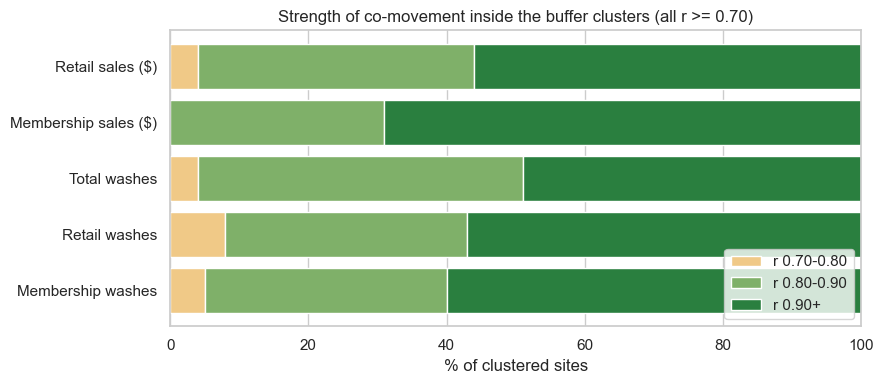

,KPI,0.70-0.80,0.80-0.90,0.90+,sites
0,Membership washes,5,35,60,144
1,Retail washes,8,35,57,195
2,Total washes,4,47,49,172
3,Membership sales ($),0,31,69,125
4,Retail sales ($),4,40,56,146


In [179]:
# --- How STRONG is the sync inside the clusters? (% in each correlation band) ---
# Every cluster already clears r >= 0.70, so this shows how tight the matches really are.
BANDS = [0.70, 0.80, 0.90, 1.01]; BAND_LBL = ["0.70-0.80", "0.80-0.90", "0.90+"]

def band_breakdown(weight_by_sites):
    rows = []
    for k in BUFFER_KPIS:
        s = summ_by_kpi[k].copy()
        s["band"] = pd.cut(s["avg_pairwise_corr"], bins=BANDS, labels=BAND_LBL, right=False)
        if weight_by_sites:
            pct = s.groupby("band")["n_sites"].sum() / s["n_sites"].sum() * 100
            tot = int(s["n_sites"].sum())
        else:
            pct = s["band"].value_counts(normalize=True) * 100
            tot = len(s)
        rows.append({"KPI": KPIS[k], **{b: round(pct.get(b, 0)) for b in BAND_LBL},
                     ("sites" if weight_by_sites else "clusters"): tot})
    return pd.DataFrame(rows)

band_sites = band_breakdown(weight_by_sites=True)
print("Share of GROUPED SITES by within-cluster correlation strength (%):")
print(band_sites.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
left = np.zeros(len(BUFFER_KPIS))
colors = ["#f0c987", "#7fb069", "#2a7f3f"]
for b, c in zip(BAND_LBL, colors):
    vals = band_sites[b].to_numpy()
    ax.barh(band_sites["KPI"], vals, left=left, label=f"r {b}", color=c)
    left += vals
ax.set_xlabel("% of clustered sites"); ax.set_xlim(0, 100)
ax.set_title("Strength of co-movement inside the buffer clusters (all r >= 0.70)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
band_sites

In [180]:
# --- Map the headline KPI clusters; export ALL per-KPI memberships to CSV ---
import folium
import matplotlib.colors as mcolors
pal = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())

cl = labels_by_kpi[HEAD]
fmap2 = folium.Map(location=[csites.lat.median(), csites.lon.median()],
                   zoom_start=4, tiles="CartoDB positron")
for pos, r in csites.iterrows():
    c = cl[pos]
    if c < 0:    # ungrouped cohort site
        folium.CircleMarker([r.lat, r.lon], radius=2, color="#dddddd",
                            fill=True, fill_opacity=.5, weight=0).add_to(fmap2)
    else:
        folium.CircleMarker([r.lat, r.lon], radius=4, color=pal[c % len(pal)],
                            fill=True, fill_opacity=.85, weight=0,
                            popup=f"{r.site_uid}<br>{KPIS[HEAD]} cluster {c}").add_to(fmap2)
fmap2.save("kpi_buffer_clusters_map.html")
print("Map saved -> kpi_buffer_clusters_map.html")

export = pd.concat([summ_by_kpi[k] for k in BUFFER_KPIS], ignore_index=True)
export.to_csv("kpi_buffer_clusters.csv", index=False)
print(f"Exported {len(export)} clusters across {len(BUFFER_KPIS)} KPIs -> kpi_buffer_clusters.csv")
fmap2

Map saved -> kpi_buffer_clusters_map.html
Exported 229 clusters across 5 KPIs -> kpi_buffer_clusters.csv


### Step 7 takeaways

- For every key KPI we now have **tight local clusters** in which *every* member site is
  within **20 km** of every other and their monthly curves correlate **≥ 0.70** — these are
  the groups of "nearby sites that genuinely behaved the same".
- The **count of sites that fall into such clusters** (see the overview table) is itself a
  measure of how locally-coherent each KPI is: KPIs where many cohort sites land in a tight
  cluster are the ones where **location predicts behaviour**; KPIs where few do are driven by
  site-specific factors instead.
- Full membership per KPI is written to **`kpi_buffer_clusters.csv`** and the headline-KPI
  map to **`kpi_buffer_clusters_map.html`** for inspection.
- These clusters are intentionally strict (clique-like, hard 20 km cap). Loosen `BUFFER_KM`
  or lower `CORR_MIN` at the top of the section to trade tightness for coverage.